## Project summary

This project analyzes Airbnb listings in Albany, NY to identify the strongest investment opportunities based on demand, location and amenities provided. The goal is to help potential Airbnb investors and hosts understand which factors improve occupancy. 

## 1. Data Processing

In [167]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy import stats
import contextily as ctx
import geopandas as gpd

In [48]:
listings_raw = pd.read_csv(Path("..") / "data" / "raw" / "listings.csv")

In [54]:
listings_raw.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260215064701,2026-02-15,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260215064701,2026-02-15,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.26
2,5651579,https://www.airbnb.com/rooms/5651579,20260215064701,2026-02-15,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.86,4.76,4.63,NaN,NaN,2,1,1,0,2.96
3,6015313,https://www.airbnb.com/rooms/6015313,20260215064701,2026-02-15,city scrape,Comfortable 3BR Home w/ Central Air | Pine Hills,Updated 3-bedroom home in Pine Hills near hosp...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,31223807,...,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
4,6623339,https://www.airbnb.com/rooms/6623339,20260215064701,2026-02-15,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,NaN,7,7,0,0,2.55


In [164]:
listings_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 85 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            453 non-null    int64  
 1   listing_url                                   453 non-null    str    
 2   scrape_id                                     453 non-null    int64  
 3   last_scraped                                  453 non-null    str    
 4   source                                        453 non-null    str    
 5   name                                          453 non-null    str    
 6   description                                   442 non-null    str    
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   453 non-null    str    
 9   host_id                                       453 non-null    int64  
 10  h

### Key insight:
This is a very large dataset with 85 columns, therefore I decided to only keep the most relevant columns and create a copy DF titled "listings" that will be used for further analysis.

In [180]:
columns_to_keep = [
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "price",
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "review_scores_rating",
    "review_scores_value",
    "review_scores_location",
    "availability_365",
    "host_is_superhost",
    "id",
    "host_response_rate",
    "amenities"
]

listings = listings_raw[columns_to_keep].copy()

In [181]:
listings.shape

(453, 22)

In [182]:
listings.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'price',
       'estimated_revenue_l365d', 'estimated_occupancy_l365d', 'room_type',
       'property_type', 'accommodates', 'bedrooms', 'bathrooms',
       'number_of_reviews', 'reviews_per_month', 'number_of_reviews_ltm',
       'review_scores_rating', 'review_scores_value', 'review_scores_location',
       'availability_365', 'host_is_superhost', 'id', 'host_response_rate',
       'amenities'],
      dtype='str')

In [183]:
listings.head()

,neighbourhood_cleansed,latitude,longitude,price,estimated_revenue_l365d,estimated_occupancy_l365d,room_type,property_type,accommodates,bedrooms,bathrooms,number_of_reviews,reviews_per_month,number_of_reviews_ltm,review_scores_rating,review_scores_value,review_scores_location,availability_365,host_is_superhost,id,host_response_rate,amenities
0,THIRD WARD,42.66,-73.75,NaN,NaN,0,Entire home/apt,Entire rental unit,4,2.00,1.00,9,0.06,0,3.56,3.67,3.22,321,f,2992450,NaN,"[""Smoke alarm"", ""Kitchen"", ""Air conditioning"",..."
1,SIXTH WARD,42.65,-73.77,NaN,NaN,60,Entire home/apt,Entire rental unit,3,1.00,1.00,317,2.26,10,4.75,4.78,4.82,301,t,3820211,NaN,"[""Smoke alarm"", ""Kitchen"", ""Dishwasher"", ""Wifi..."
2,SECOND WARD,42.65,-73.76,NaN,NaN,120,Entire home/apt,Entire rental unit,2,0.00,1.00,389,2.96,20,4.51,4.63,4.76,35,f,5651579,NaN,"[""Smoke alarm"", ""Kitchen"", ""Wifi"", ""Shower gel..."
3,THIRTEENTH WARD,42.67,-73.79,NaN,NaN,0,Entire home/apt,Entire home,8,3.00,2.00,0,NaN,0,NaN,NaN,NaN,324,f,6015313,NaN,"[""Smoke alarm"", ""Kitchen"", ""Gas stove"", ""Wifi""..."
4,SIXTH WARD,42.65,-73.77,NaN,NaN,6,Entire home/apt,Entire rental unit,2,1.00,1.00,332,2.55,1,4.73,4.72,4.80,348,t,6623339,NaN,"[""Smoke alarm"", ""Kitchen"", ""Dishwasher"", ""Wifi..."


In [184]:
listings.isna().sum()

neighbourhood_cleansed         0
latitude                       0
longitude                      0
price                        453
estimated_revenue_l365d      453
estimated_occupancy_l365d      0
room_type                      0
property_type                  0
accommodates                   0
bedrooms                       3
bathrooms                     16
number_of_reviews              0
reviews_per_month             58
number_of_reviews_ltm          0
review_scores_rating          58
review_scores_value           58
review_scores_location        58
availability_365               0
host_is_superhost              0
id                             0
host_response_rate           453
amenities                      0
dtype: int64

### Key insight:
The preliminary analysis of the data is showing a significant amount of N/A values. 

Price, estimated revenue and host_response_rate don't have any data and therefore will be removed from the list going forward. The project will focus on occupancy and demand instead of revenue to predict a good areas of investment.

In [185]:
final_columns_to_keep = [
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "estimated_occupancy_l365d",
    "room_type",
    "property_type",
    "accommodates",
    "bedrooms",
    "bathrooms",
    "number_of_reviews",
    "reviews_per_month",
    "number_of_reviews_ltm",
    "review_scores_rating",
    "review_scores_value",
    "review_scores_location",
    "availability_365",
    "host_is_superhost",
    "amenities",
    "id"
]

listings_final = listings_raw[final_columns_to_keep].copy()

### Handling N/As
**1.** To deal with the remaining N/A values in bedrooms and bathrooms columns I have filled them with medians, because it's important structural information for this analysis and I don't want to drop the entire lines of data. 

**2.** reviews_per_month, review_scores_rating, review_scores_value, and review_score_location all have 58 N/A values. This amount of N/As could be due to new Airbnbs with no reviews yet or simply low demand, therefore those columns will be filled with 0s.

In [65]:
listings_final["bedrooms"] = listings_final["bedrooms"].fillna(listings_final["bedrooms"].median())
listings_final["bathrooms"] = listings_final["bathrooms"].fillna(listings_final["bathrooms"].median())

In [67]:
listings_final["bedrooms"].isna().sum()

np.int64(0)

In [68]:
listings_final["bathrooms"].isna().sum()

np.int64(0)

In [69]:
rating_cols = [
    "review_scores_rating",
    "review_scores_value",
    "reviews_per_month",
    "review_scores_location"
]
listings_final[rating_cols] = listings_final[rating_cols].fillna(0)

In [229]:
listings_final[rating_cols].isna().sum()

review_scores_rating      58
review_scores_value       58
reviews_per_month         58
review_scores_location    58
dtype: int64

### Checking for duplicates with ID
Each listing should have a unique ID, hence checking for any duplicate values in this column would reveal duplicate listings. No duplicates were found.

In [71]:
listings_final["id"].duplicated().sum()

np.int64(0)

### Checking for incorrect data types
I uncovered that neighbourhood_cleansed, room_type, property_type, and host_is_superhost are strings. To improve performance I will convert them into categories. All other data types are correct.

In [186]:
listings_final.dtypes

neighbourhood_cleansed           str
latitude                     float64
longitude                    float64
estimated_occupancy_l365d      int64
room_type                        str
property_type                    str
accommodates                   int64
bedrooms                     float64
bathrooms                    float64
number_of_reviews              int64
reviews_per_month            float64
number_of_reviews_ltm          int64
review_scores_rating         float64
review_scores_value          float64
review_scores_location       float64
availability_365               int64
host_is_superhost                str
amenities                        str
id                             int64
dtype: object

In [230]:
categorical_cols = [
    "neighbourhood_cleansed",
    "room_type",
    "property_type",
    "host_is_superhost"
]

for col in categorical_cols:
    listings_final[col] = listings_final[col].astype("category")

In [231]:
listings_final.dtypes

neighbourhood_cleansed       category
latitude                      float64
longitude                     float64
estimated_occupancy_l365d       int64
room_type                    category
property_type                category
accommodates                    int64
bedrooms                      float64
bathrooms                     float64
number_of_reviews               int64
reviews_per_month             float64
number_of_reviews_ltm           int64
review_scores_rating          float64
review_scores_value           float64
review_scores_location        float64
availability_365                int64
host_is_superhost            category
amenities                         str
id                              int64
amenities_list                 object
amenity_count                   int64
has_full_kitchen                int64
has_laundry                     int64
has_parking                     int64
has_self_checkin                int64
has_workspace                   int64
has_air_cond

### Data validation 

In [188]:
listings_final.describe(include="all")

,neighbourhood_cleansed,latitude,longitude,estimated_occupancy_l365d,room_type,property_type,accommodates,bedrooms,bathrooms,number_of_reviews,reviews_per_month,number_of_reviews_ltm,review_scores_rating,review_scores_value,review_scores_location,availability_365,host_is_superhost,amenities,id
count,453,453.00,453.00,453.00,453,453,453.00,450.00,437.00,453.00,395.00,453.00,395.00,395.00,395.00,453.00,453,453,453.00
unique,15,NaN,NaN,NaN,2,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,443,NaN
top,SIXTH WARD,NaN,NaN,NaN,Entire home/apt,Entire rental unit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,"[""Smoke alarm"", ""Kitchen"", ""Dishwasher"", ""Shar...",NaN
freq,106,NaN,NaN,NaN,339,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,241,3,NaN
mean,NaN,42.66,-73.78,79.62,NaN,NaN,3.44,1.60,1.23,61.57,1.84,13.87,4.73,4.69,4.63,258.17,NaN,NaN,898191702499860480.00
std,NaN,0.01,0.02,84.20,NaN,NaN,2.44,1.17,0.64,114.67,1.89,19.27,0.38,0.40,0.45,115.81,NaN,NaN,570127476167009280.00
min,NaN,42.63,-73.88,0.00,NaN,NaN,1.00,0.00,0.00,0.00,0.03,0.00,2.50,2.50,2.00,0.00,NaN,NaN,2992450.00
25%,NaN,42.65,-73.79,6.00,NaN,NaN,2.00,1.00,1.00,3.00,0.42,1.00,4.67,4.63,4.50,175.00,NaN,NaN,593272120497643136.00
50%,NaN,42.66,-73.77,54.00,NaN,NaN,2.00,1.00,1.00,18.00,1.23,6.00,4.85,4.81,4.79,307.00,NaN,NaN,1020518500251473024.00
75%,NaN,42.67,-73.76,126.00,NaN,NaN,4.00,2.00,1.00,68.00,2.58,18.00,4.97,4.93,4.93,357.00,NaN,NaN,1383910626115273728.00


### Key insights
1. There are 15 unique values in neighbourhood_cleansed, where I want to ensure all values are standardized.
2. There are 18 unique values in property_type, where I want to ensure all values are standardized.
3. The minimum value for both bathooms and bedrooms is 0, which are most likely studios and shared bathroom properties. I will check the distribution of those values but will not exclude them. 

In [83]:
sorted(listings_final["neighbourhood_cleansed"].unique())

['EIGHTH WARD',
 'ELEVENTH WARD',
 'FIFTEENTH WARD',
 'FIFTH WARD',
 'FIRST WARD',
 'FOURTEENTH WARD',
 'FOURTH WARD',
 'NINTH WARD',
 'SECOND WARD',
 'SEVENTH WARD',
 'SIXTH WARD',
 'TENTH WARD',
 'THIRD WARD',
 'THIRTEENTH WARD',
 'TWELFTH WARD']

In [86]:
sorted(listings_final["property_type"].unique())

['Entire condo',
 'Entire cottage',
 'Entire guest suite',
 'Entire guesthouse',
 'Entire home',
 'Entire loft',
 'Entire place',
 'Entire rental unit',
 'Entire townhouse',
 'Entire vacation home',
 'Private room in bed and breakfast',
 'Private room in condo',
 'Private room in guest suite',
 'Private room in home',
 'Private room in rental unit',
 'Private room in townhouse',
 'Private room in villa',
 'Room in hotel']

In [223]:
def detailed_property_type(x):
    if "Entire" in x:
        return "Entire place"
    elif "Private room" in x:
        return "Private room"
    elif "Room in hotel" in x:
        return "Hotel room"
    else:
        return "Other"

listings_final["property_type_grouped"] = listings_final["property_type"].apply(detailed_property_type)

In [224]:
sorted(listings_final["property_type_grouped"].unique())

['Entire place', 'Hotel room', 'Private room']

In [90]:
listings_final["bedrooms"].value_counts().sort_index()

bedrooms
0.0     18
1.0    275
2.0     89
3.0     41
4.0     18
5.0      6
6.0      2
7.0      1
8.0      2
9.0      1
Name: count, dtype: int64

In [91]:
listings_final["bathrooms"].value_counts().sort_index()

bathrooms
0.0      3
0.5      1
1.0    363
1.5     25
2.0     40
2.5      4
3.0      8
3.5      3
4.0      4
5.5      1
7.0      1
Name: count, dtype: int64

### Key insight:
The distribution of bedroom and bathroom counts seems reasonable and therefore needs no action.

## Parsing the amenities list
The amenities column contains a list of all amenities offered by each property. To be able to access this information and use it for analysis I will be parsing the list to see all unique values. 

In [191]:
import ast

def parse_amenities(value):
    if pd.isna(value):
        return []
    
    if isinstance(value, list):
        return value
    
    try:
        return ast.literal_eval(value)
    except:
        return []

listings_final["amenities_list"] = listings_final["amenities"].apply(parse_amenities)

In [204]:
unique_amenities = sorted(
    listings_final["amenities_list"]
    .explode()
    .dropna()
    .unique()
)

unique_amenities

['32 inch HDTV with Amazon Prime Video',
 '32 inch HDTV with Amazon Prime Video, Netflix, DVD player',
 '32 inch HDTV with HBO Max, Roku, standard cable, Hulu, Amazon Prime Video, Netflix',
 '32 inch TV',
 '40 inch HDTV with Amazon Prime Video, Disney+, HBO Max, Netflix',
 '40 inch HDTV with Fire TV, Netflix, Amazon Prime Video, Disney+, HBO Max, Hulu',
 '40 inch HDTV with Hulu, Netflix, Fire TV, Disney+, HBO Max, Amazon Prime Video',
 '40 inch HDTV with Netflix',
 '40 inch HDTV with Netflix, Hulu, Amazon Prime Video',
 '40 inch HDTV with Roku, Netflix',
 '40 inch HDTV with standard cable',
 '40 inch TV with Amazon Prime Video, Netflix, Roku, Fire TV',
 '42 inch HDTV with Amazon Prime Video, Chromecast, Fire TV',
 '42 inch HDTV with Roku',
 '42 inch TV',
 '42 inch TV with Amazon Prime Video, Hulu, Netflix, Roku',
 '43 inch HDTV',
 '50 inch HDTV with Amazon Prime Video, Hulu, Disney+, Netflix, Roku, Chromecast, Apple TV, HBO Max',
 '50 inch HDTV with HBO Max, Disney+, Apple TV, Hulu, st

### Key insights:
**1.** The list of amenities is very long, messy and contains low value data such as "suave conditioner" or "shower gel"

**2.** I will create binary columns like has_kitchen, has_parking etc. to separate the data into insightful categories. 

**3.** New columns will not be created for specific product brands or TV sizes to streamline the data.

In [205]:
def clean_text(text):
    return str(text).casefold().replace("\xa0", " ").replace("–", "-").strip()


def has_any_amenity(amenities, keywords, exclude_keywords=None):
    if exclude_keywords is None:
        exclude_keywords = []
    
    for amenity in amenities:
        amenity_clean = clean_text(amenity)
        
        if any(exclude in amenity_clean for exclude in exclude_keywords):
            continue
        
        if any(keyword in amenity_clean for keyword in keywords):
            return 1
    
    return 0


def count_matching_amenities(amenities, keywords):
    count = 0
    
    for amenity in amenities:
        amenity_clean = clean_text(amenity)
        
        if any(keyword in amenity_clean for keyword in keywords):
            count += 1
    
    return count

In [206]:
# Total number of amenities
listings_final["amenity_count"] = listings_final["amenities_list"].apply(len)


# Kitchen / cooking
kitchen_keywords = [
    "kitchen", "kitchenette", "cooking basics", "dishes and silverware",
    "microwave", "oven", "stove", "refrigerator", "freezer",
    "coffee maker", "dishwasher", "toaster", "dining table",
    "blender", "baking sheet", "rice maker"
]

listings_final["has_full_kitchen"] = listings_final["amenities_list"].apply(
    lambda amenities: int(
        has_any_amenity(amenities, ["kitchen", "kitchenette"]) == 1
        or count_matching_amenities(amenities, kitchen_keywords) >= 3
    )
)


# Laundry
listings_final["has_laundry"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["washer", "dryer", "laundromat", "drying rack"]
    )
)


# Parking / transportation
listings_final["has_parking"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["parking", "garage", "driveway", "carport", "ev charger", "street parking"]
    )
)


# Self check-in / easy access
listings_final["has_self_checkin"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["self check-in", "keypad", "lockbox", "smart lock"]
    )
)


# Workspace / remote work
listings_final["has_workspace"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["dedicated workspace", "ethernet connection", "fast wifi"]
    )
)


# Air conditioning
listings_final["has_air_conditioning"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["air conditioning", "central air conditioning", "window ac", "portable air conditioning", "ac -"]
    )
)


# Outdoor space
listings_final["has_outdoor_space"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["backyard", "patio", "balcony", "outdoor furniture", "outdoor dining", 
         "outdoor kitchen", "bbq grill", "fire pit", "hammock", "sun loungers"]
    )
)


# Family-friendly amenities
listings_final["has_family_friendly"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["crib", "high chair", "children", "baby", "pack", "outlet covers",
         "window guards", "table corner guards", "fireplace guards", "changing table",
         "babysitter", "safety gates"]
    )
)


# Premium leisure amenities
listings_final["has_premium_leisure"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["pool", "hot tub", "gym", "sauna", "exercise equipment", 
         "bowling alley", "mini golf", "climbing wall"],
        exclude_keywords=["pool table", "pool view"]
    )
)


# Views / water access
listings_final["has_view_or_water_access"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["view", "waterfront", "lake access", "river view", "city skyline"]
    )
)


# Pets
listings_final["allows_pets"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["pets allowed"]
    )
)


# Entertainment
listings_final["has_entertainment"] = listings_final["amenities_list"].apply(
    lambda amenities: has_any_amenity(
        amenities,
        ["tv", "hdtv", "netflix", "roku", "hulu", "amazon prime", "disney+",
         "hbo max", "apple tv", "chromecast", "fire tv", "game console",
         "board games", "books and reading", "sound system", "record player",
         "arcade games", "movie theater", "piano", "ping pong table", "pool table"]
    )
)

In [207]:
amenity_feature_cols = [
    "amenity_count",
    "has_full_kitchen",
    "has_laundry",
    "has_parking",
    "has_self_checkin",
    "has_workspace",
    "has_air_conditioning",
    "has_outdoor_space",
    "has_family_friendly",
    "has_premium_leisure",
    "has_view_or_water_access",
    "allows_pets",
    "has_entertainment"
]

listings_final[amenity_feature_cols].head()

,amenity_count,has_full_kitchen,has_laundry,has_parking,has_self_checkin,has_workspace,has_air_conditioning,has_outdoor_space,has_family_friendly,has_premium_leisure,has_view_or_water_access,allows_pets,has_entertainment
0,8,1,0,0,0,0,1,0,0,0,0,0,1
1,33,1,1,1,1,1,1,0,0,0,0,1,1
2,40,1,1,1,1,1,1,1,0,0,0,0,1
3,33,1,1,1,1,0,1,1,0,0,0,0,1
4,44,1,1,1,1,1,1,1,0,0,0,1,1


### Summary after data processing
1. There are no N/A values remaining
   
3. There are no impossible values
   
5. All names are standardized, there are no duplicates and data is separated into relevant category bins. 

As the last step I will reset the index and then save clean data to listings_clean.csv

In [208]:
listings_final = listings_final.reset_index(drop=True)

In [226]:
listings_final.to_csv("../data/processed/listings_clean.csv", index=False)

## 2. Exploratory Data Analysis 

In [102]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [210]:
listings_final.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,453.00,42.66,0.01,42.63,42.65,42.66,42.67,42.71
longitude,453.00,-73.78,0.02,-73.88,-73.79,-73.77,-73.76,-73.74
estimated_occupancy_l365d,453.00,79.62,84.20,0.00,6.00,54.00,126.00,255.00
accommodates,453.00,3.44,2.44,1.00,2.00,2.00,4.00,16.00
bedrooms,450.00,1.60,1.17,0.00,1.00,1.00,2.00,9.00
bathrooms,437.00,1.23,0.64,0.00,1.00,1.00,1.00,7.00
number_of_reviews,453.00,61.57,114.67,0.00,3.00,18.00,68.00,972.00
reviews_per_month,395.00,1.84,1.89,0.03,0.42,1.23,2.58,10.44
number_of_reviews_ltm,453.00,13.87,19.27,0.00,1.00,6.00,18.00,127.00
review_scores_rating,395.00,4.73,0.38,2.50,4.67,4.85,4.97,5.00


### Key insights from  the .describe summary_
**1.** In the "estimated_occupancy_l365d" column mean is much higher than the median and the standard deviation is very large, suggesting occupancy is strongly skewed upward by a smaller number of highly occupied listings.

**2.** The "accomodates" column shows a small mean of 3.44 and median of 2. Likewise, in the "bedrooms" column the mean is 1.59 and median is 1, suggesting that the market is dominated by smaller properites, which are mostly 1 bedroom properties accomodating couples.

**3.** "Number_of_reviews" column shows a max number of 972 reviews with a median of only 30, suggesting that a small number of listings recieve substantially more guest engagement than the typical property, which is likely correlating with occupancy.

**4.** Lastly, the overall review scores were high aross the listings, suggesting a generally positive consumer experience. 

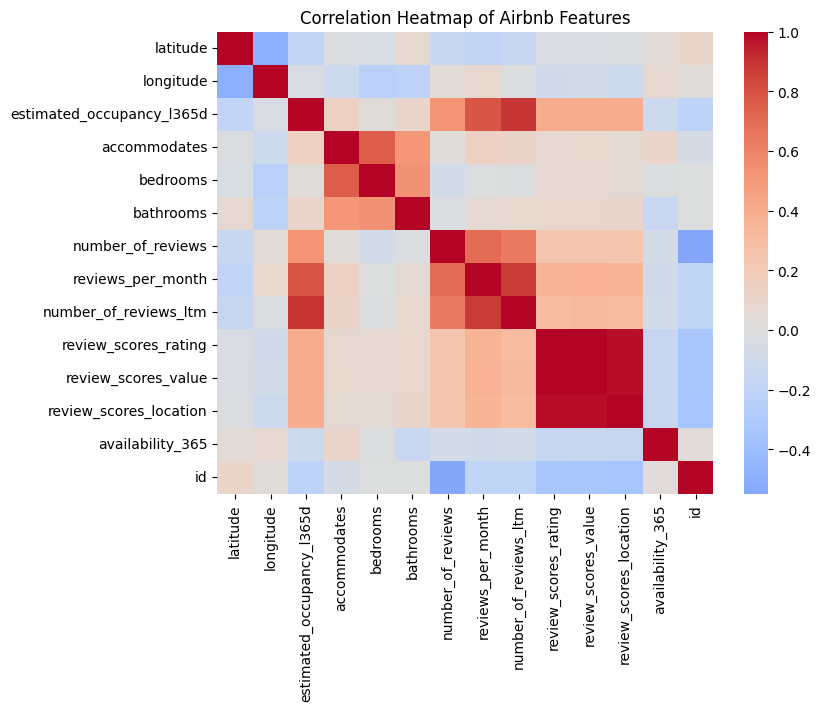

In [110]:
numeric_df = listings_final.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Airbnb Features")
plt.show()

### Key insights
The correlation heatmap did not reveal many strong relationships, however the positive relationships between Estimated Occupancy and Reviews stood out.

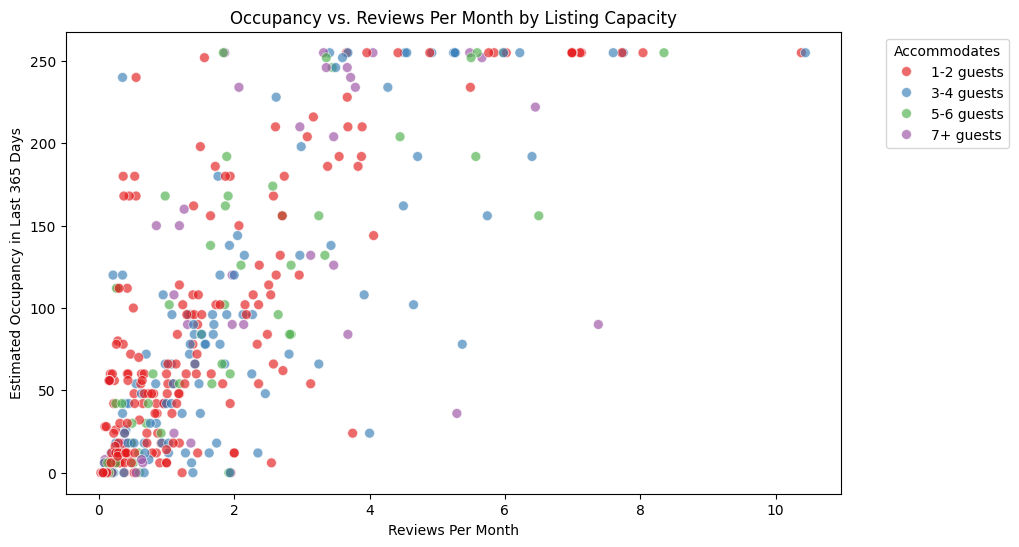

In [232]:
plot_df = listings_final[
    ["reviews_per_month", "estimated_occupancy_l365d", "accommodates"]
]

plot_df["capacity_group"] = pd.cut(
    plot_df["accommodates"],
    bins=[0, 2, 4, 6, 20],
    labels=["1-2 guests", "3-4 guests", "5-6 guests", "7+ guests"]
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="reviews_per_month",
    y="estimated_occupancy_l365d",
    hue="capacity_group",
    palette="Set1",
    alpha=0.65,
    s=50
)

plt.title("Occupancy vs. Reviews Per Month by Listing Capacity")
plt.xlabel("Reviews Per Month")
plt.ylabel("Estimated Occupancy in Last 365 Days")
plt.legend(title="Accommodates", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Scatter plot insight:
**1.** Occupancy does seem to be positively correlated with Reviews per month but the pattern is very dispersed. 

**2.** Accomodates variable is also very dispersed, suggesting that the listing capacity does not affect occupancy. 


In [233]:
output_folder = Path("..") / "Outputs" / "Figures"
output_folder.mkdir(parents=True, exist_ok=True)

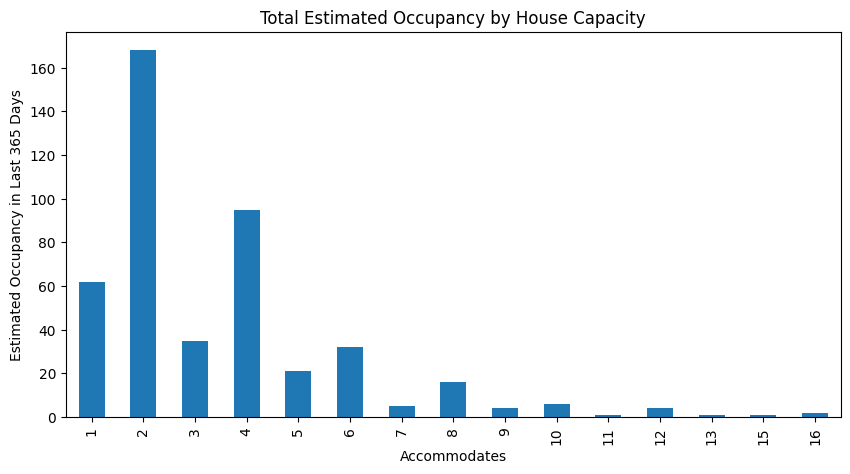

In [234]:
occupancy_by_size = listings_final.groupby("accommodates")["estimated_occupancy_l365d"].count()

plt.figure(figsize=(10,5))
occupancy_by_size.plot(kind="bar")

plt.title("Total Estimated Occupancy by House Capacity")
plt.xlabel("Accommodates")
plt.ylabel("Estimated Occupancy in Last 365 Days")

plt.savefig(
    output_folder / "occupancy_by_house_capacity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Bar chart insight
This chart suggests that the mostly occupied properties only accomodate 1-4 people. Larger properties have much less occupancy in the last 365 days.

## Neighborhood analysis
Using the latitude and longitude I created a geographical chart that shows listings separated into groups by occupancy levels.

The added map in the background makes it easier to understand where the different neighborhoods are located on the map

In [215]:
map_df = listings_final[
    ["latitude", "longitude", "estimated_occupancy_l365d", "neighbourhood_cleansed"]
].dropna().copy()

map_df["occupancy_group"] = pd.qcut(
    map_df["estimated_occupancy_l365d"],
    q=4,
    labels=["Low", "Medium-Low", "Medium-High", "High"]
)

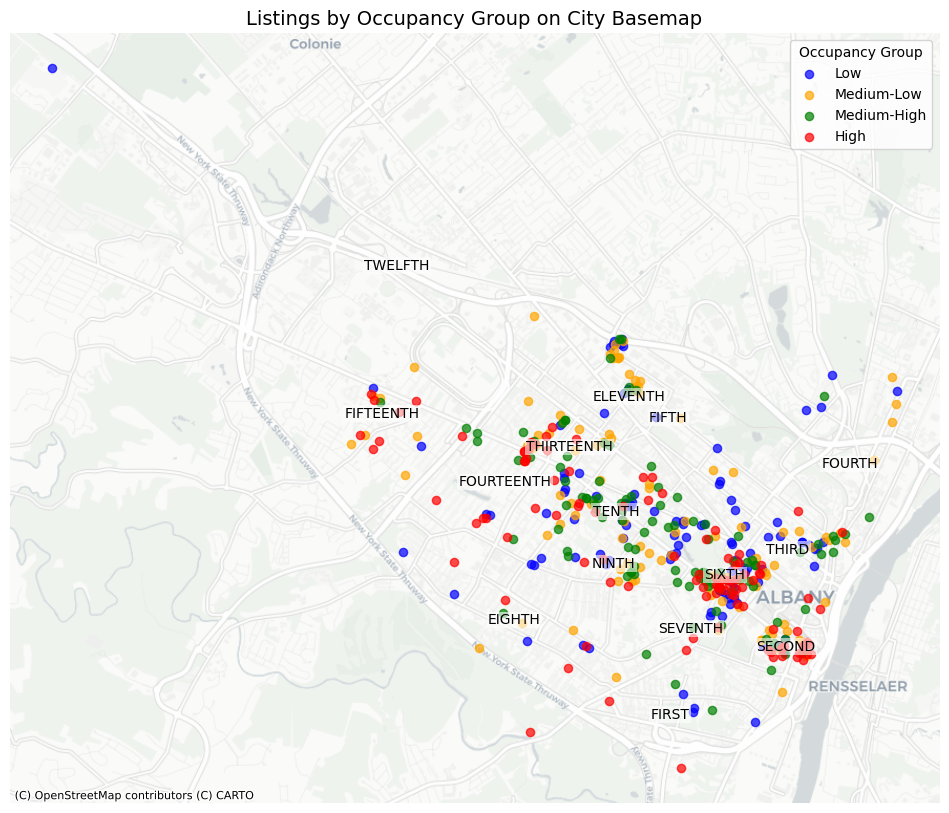

In [235]:
gdf = gpd.GeoDataFrame(
    map_df,
    geometry=gpd.points_from_xy(map_df["longitude"], map_df["latitude"]),
    crs="EPSG:4326"
)

# Convert to Web Mercator for compatibility with basemaps
gdf = gdf.to_crs(epsg=3857)

# Compute ward center points using average lat/lon
ward_centers = (
    map_df.groupby("neighbourhood_cleansed")[["latitude", "longitude"]]
    .mean()
    .reset_index()
)

ward_gdf = gpd.GeoDataFrame(
    ward_centers,
    geometry=gpd.points_from_xy(ward_centers["longitude"], ward_centers["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Color map for occupancy groups
colors = {
    "Low": "blue",
    "Medium-Low": "orange",
    "Medium-High": "green",
    "High": "red"
}

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

for group, color in colors.items():
    subset = gdf[gdf["occupancy_group"] == group]
    subset.plot(
        ax=ax,
        markersize=35,
        color=color,
        alpha=0.7,
        label=group
    )

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

# Add ward labels
for x, y, label in zip(
    ward_gdf.geometry.x,
    ward_gdf.geometry.y,
    ward_gdf["neighbourhood_cleansed"]
):
    ax.text(
        x, y,
        label.replace(" WARD", ""),
        fontsize=10,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1)
    )

# Clean up axes
ax.set_title("Listings by Occupancy Group on City Basemap", fontsize=14)
ax.set_axis_off()
ax.legend(title="Occupancy Group")

fig.savefig(output_folder / "occupancy_static_map.png", dpi=300, bbox_inches="tight")

plt.show()

### Key insights:
1. Second and Sixth Wards stand out as mostly populated and have high occupancy.
2. However, there is no clear geographical trend. High and low occupancy properties are found in every area
3. Most properties seem to be clustered around Albany's downtown area. 

## 4. Analysis Depth 

In [119]:
cat_cols = [
    "room_type",
    "property_type",
    "host_is_superhost",
    "neighbourhood_cleansed"
]

target = "estimated_occupancy_l365d"


dummies = pd.get_dummies(
    listings_final[cat_cols],
    drop_first=False
)


dummy_corr_df = pd.concat(
    [dummies, listings_final[target]],
    axis=1
)

In [125]:
category_corr = dummy_corr_df.corr()[target].drop(target).sort_values(ascending=False)

category_corr.head(50)

host_is_superhost_t                                0.38
neighbourhood_cleansed_SECOND WARD                 0.16
neighbourhood_cleansed_FOURTEENTH WARD             0.15
property_type_Entire townhouse                     0.14
property_type_Private room in guest suite          0.11
property_type_Entire place                         0.10
property_type_Entire guest suite                   0.09
neighbourhood_cleansed_FIFTEENTH WARD              0.09
property_type_Entire loft                          0.08
neighbourhood_cleansed_SIXTH WARD                  0.08
room_type_Entire home/apt                          0.06
property_type_Entire condo                         0.05
property_type_Private room in townhouse            0.04
property_type_Entire vacation home                 0.03
property_type_Entire cottage                       0.02
neighbourhood_cleansed_THIRTEENTH WARD             0.01
property_type_Entire home                          0.01
neighbourhood_cleansed_FIRST WARD               

### Key finding from this correlation analysis
**1.** Most categorical features, such as neighborhood, property type, and room type, have weak relationships with estimated occupancy when analyzed individually.

**2.** The strongest correlation suggests that the Superhost status appears to be moderately associated with higher estimated occupancy.


In [128]:
superhost_summary = listings_final.groupby("host_is_superhost")["estimated_occupancy_l365d"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).round(2)

superhost_summary

,count,mean,median,std
host_is_superhost,,,,
f,241,49.65,12.00,71.09
t,212,113.69,96.00,85.11


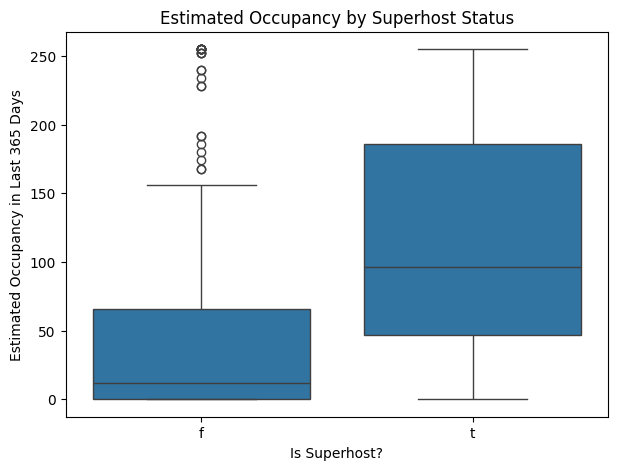

In [217]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=listings_final,
    x="host_is_superhost",
    y="estimated_occupancy_l365d"
)

plt.title("Estimated Occupancy by Superhost Status")
plt.xlabel("Is Superhost?")
plt.ylabel("Estimated Occupancy in Last 365 Days")

plt.savefig(
    output_folder / "Estimates Occupancy by Superhost Status.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Key findings from group.by analysis
**1.** Superhost listings had more than double the average estimated occupancy of non-superhost listings

**2.** The typical superhost listing had about 8 times higher median occupancy than the typical non-superhost listing.

**3.** The mean and median in the non-superhost group are very far apart, suggesting that most non-superhosts have low occupancy, but a few high-performing non-superhosts pull the average upward. In the superhost group the mean and median are closer together, which suggests superhost listings are more consistently occupied.

In [131]:
superhost_occ = listings_final.loc[
    listings_final["host_is_superhost"] == "t",
    "estimated_occupancy_l365d"
].dropna()

non_superhost_occ = listings_final.loc[
    listings_final["host_is_superhost"] == "f",
    "estimated_occupancy_l365d"
].dropna()

t_stat, p_value = stats.ttest_ind(
    superhost_occ,
    non_superhost_occ,
    equal_var=False
)

t_stat, p_value

(np.float64(8.624799921553121), np.float64(1.3950119570933035e-16))

In [132]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is evidence that average occupancy differs between superhosts and non-superhosts.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is not strong evidence that average occupancy differs between the groups.")

Reject the null hypothesis.
There is evidence that average occupancy differs between superhosts and non-superhosts.


### Key findings from Welch’s t-test
**1.** The results showed a statistically significant difference between the two groups, t = 8.62, p < 0.001. Superhost listings had a much higher average estimated occupancy of 113.69 days compared with 49.65 days for non-superhost listings. This suggests that superhost status is strongly associated with higher listing performance.

**2.** However, this result shows an association, not causation. The analysis does not prove that becoming a superhost directly causes higher occupancy, because other factors such as location, pricing, listing quality, and review history may also influence performance.

### Groupby analysis of occupancy by neighborhood

In [136]:
neighborhood_summary = listings_final.groupby("neighbourhood_cleansed")["estimated_occupancy_l365d"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
).round(2)

neighborhood_summary.sort_values("median", ascending=False)

,count,mean,median,std
neighbourhood_cleansed,,,,
FOURTEENTH WARD,29,126.52,126.00,93.27
FIFTEENTH WARD,15,120.67,108.00,104.10
SECOND WARD,43,122.21,108.00,95.69
FIRST WARD,9,85.67,84.00,92.02
SEVENTH WARD,13,82.62,66.00,73.78
SIXTH WARD,106,91.04,60.00,93.77
THIRTEENTH WARD,39,83.64,56.00,76.22
TENTH WARD,49,52.78,54.00,52.91
NINTH WARD,36,58.81,42.00,66.73


### Key insights
**1.** The Sixth Ward contains the largest number of listings, but its median occupancy is lower than the top-performing neighborhoods. This suggests it may be a more competitive or saturated area.

**2.** The Fourteenth, Second, and Fifteenth Wards had the highest typical estimated occupancy, suggesting these neighborhoods may be stronger-performing areas for Airbnb listings.

**3.** The Eighth Ward showed a large gap between mean and median occupancy, suggesting that performance in this neighborhood is highly uneven and may be driven by a small number of successful listings. This could indicate that this area may have high potential, but performance is inconsistent.

### Neighborhood + superhost analysis
Are the best-performing neighborhoods truly stronger locations, or do they just have more superhosts?

In [162]:
neighborhood_profile = listings_final.groupby("neighbourhood_cleansed").agg(
    listings=("id", "count"),
    mean_occupancy=("estimated_occupancy_l365d", "mean"),
    median_occupancy=("estimated_occupancy_l365d", "median"),
    superhost_rate=("host_is_superhost", lambda x: (x == "t").mean()),
    median_reviews_per_month=("reviews_per_month", "median")
).round(2)

neighborhood_profile["superhost_rate_pct"] = (
    neighborhood_profile["superhost_rate"] * 100
).round(1)

neighborhood_profile.sort_values("median_occupancy", ascending=False)

,listings,mean_occupancy,median_occupancy,superhost_rate,median_reviews_per_month,superhost_rate_pct
neighbourhood_cleansed,,,,,,
FOURTEENTH WARD,29,126.52,126.00,0.72,1.72,72.00
FIFTEENTH WARD,15,120.67,108.00,0.80,1.11,80.00
SECOND WARD,43,122.21,108.00,0.28,2.13,28.00
FIRST WARD,9,85.67,84.00,0.33,0.35,33.00
SEVENTH WARD,13,82.62,66.00,0.46,1.24,46.00
SIXTH WARD,106,91.04,60.00,0.49,1.34,49.00
THIRTEENTH WARD,39,83.64,56.00,0.85,0.85,85.00
TENTH WARD,49,52.78,54.00,0.65,0.42,65.00
NINTH WARD,36,58.81,42.00,0.47,0.52,47.00


### Key insights:
**1.** The Fourteenth, Fifteenth, and Second Wards have the highest median occupancy, but they do not all have the same superhost pattern.

**2.** The Second Ward is interesting because it has high occupancy despite a lower superhost rate, suggesting that Second Ward may be strong because of location itself, not just because it has many superhosts.

**3.** Second Ward also has the most reviews per month, suggesting this neighborhood has high guest activity and demand. 

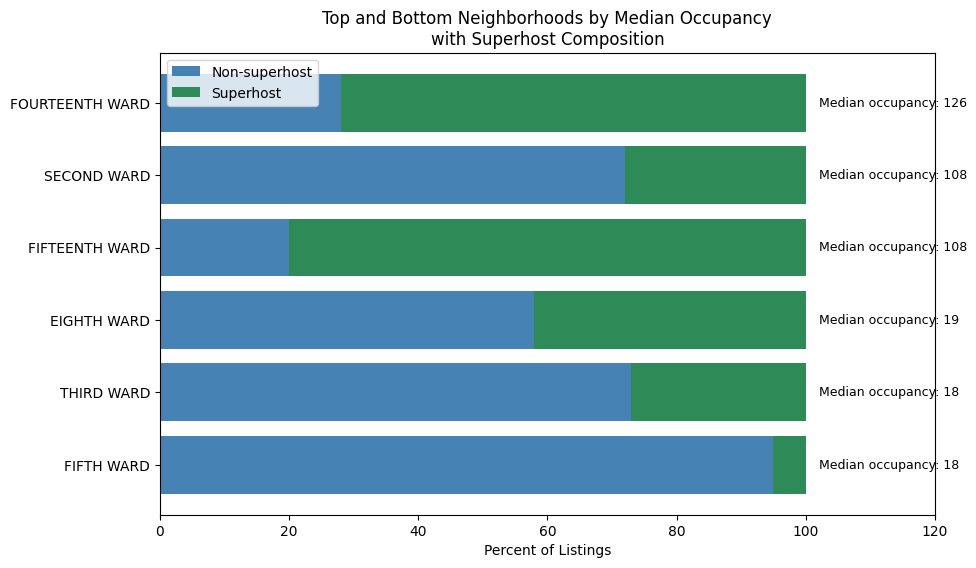

In [218]:
plot_df = neighborhood_profile.reset_index().copy()

plot_df = plot_df[plot_df["listings"] >= 10]

# Keep top 3 and bottom 3 neighborhoods by median occupancy
top_3 = plot_df.sort_values("median_occupancy", ascending=False).head(3)
bottom_3 = plot_df.sort_values("median_occupancy", ascending=True).head(3)

top_bottom = pd.concat([top_3, bottom_3]).sort_values("median_occupancy")

# Create non-superhost percentage
top_bottom["non_superhost_rate_pct"] = 100 - top_bottom["superhost_rate_pct"]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_bottom["neighbourhood_cleansed"],
    top_bottom["non_superhost_rate_pct"],
    color="steelblue",
    label="Non-superhost"
)

ax.barh(
    top_bottom["neighbourhood_cleansed"],
    top_bottom["superhost_rate_pct"],
    left=top_bottom["non_superhost_rate_pct"],
    color="seagreen",
    label="Superhost"
)

# Add median occupancy labels
for i, row in top_bottom.iterrows():
    ax.text(
        102,
        list(top_bottom.index).index(i),
        f'Median occupancy: {row["median_occupancy"]:.0f}',
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 120)
ax.set_xlabel("Percent of Listings")
ax.set_title("Top and Bottom Neighborhoods by Median Occupancy\nwith Superhost Composition")
ax.legend()

plt.savefig(
    output_folder / "Top and bottom neighborhoods by median occupancy and superhost.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Property type + occupancy analysis

In [175]:
property_summary = listings_final.groupby("property_type_grouped").agg(
    listings=("id", "count"),
    mean_occupancy=("estimated_occupancy_l365d", "mean"),
    median_occupancy=("estimated_occupancy_l365d", "median"),
    median_reviews_per_month=("reviews_per_month", "median")
).round(2)

property_summary["listing_share_pct"] = (
    property_summary["listings"] / property_summary["listings"].sum() * 100
).round(1)

property_summary.sort_values("listings", ascending=False)

,listings,mean_occupancy,median_occupancy,median_reviews_per_month,listing_share_pct
property_type_grouped,,,,,
Entire place,339,82.46,56.00,1.19,74.80
Private room,107,74.66,48.00,0.51,23.60
Hotel room,7,18.00,6.00,0.17,1.50


### Key insight
The market is overwhelmingly dominated by entire-place listings. Entire places make up nearly three-fourths of all listings and also have the highest median occupancy and review activity, but the occupancy gap between entire places and private rooms is modest.

### Property type composition in Top vs Bottom neighborhoods

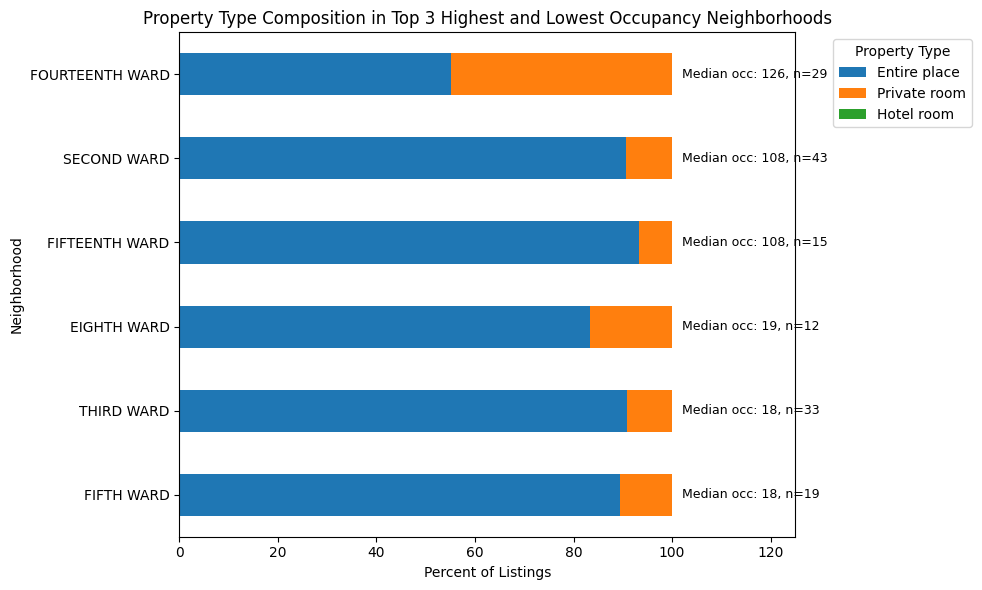

In [227]:
selected_neighborhoods = top_bottom["neighbourhood_cleansed"]

# Filter to selected neighborhoods only
property_plot_df = listings_final[
    listings_final["neighbourhood_cleansed"].isin(selected_neighborhoods)
].copy()

# Calculate property type share within each selected neighborhood
property_type_mix = pd.crosstab(
    property_plot_df["neighbourhood_cleansed"],
    property_plot_df["property_type_grouped"],
    normalize="index"
) * 100

# Keep same order as previous top_bottom chart
property_type_mix = property_type_mix.reindex(selected_neighborhoods)

# Make sure all expected columns exist
property_cols = ["Entire place", "Private room", "Hotel room"]
property_type_mix = property_type_mix.reindex(columns=property_cols, fill_value=0)

# Lookup table for median occupancy and listing count
top_bottom_lookup = top_bottom.set_index("neighbourhood_cleansed")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

property_type_mix.plot(
    kind="barh",
    stacked=True,
    ax=ax
)

# Add labels
for i, neighborhood in enumerate(property_type_mix.index):
    median_occ = top_bottom_lookup.loc[neighborhood, "median_occupancy"]
    listing_count = top_bottom_lookup.loc[neighborhood, "listings"]
    
    ax.text(
        102,
        i,
        f"Median occ: {median_occ:.0f}, n={listing_count:.0f}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 125)
ax.set_xlabel("Percent of Listings")
ax.set_ylabel("Neighborhood")
ax.set_title("Property Type Composition in Top 3 Highest and Lowest Occupancy Neighborhoods")
ax.legend(title="Property Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.savefig(
    output_folder / "Top and bottom 3 neighborhoods by occupancy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

### Key insights:
**1.** The chart shows that entire-place listings are the dominant listing type across both high- and low-occupancy neighborhoods. This suggests that property type alone does not explain neighborhood performance.

**2.** Forteenth Ward stands out, because it has the largest portion of prive room listings while having the highest occupancy, suggesting that this area may be valuable despite the property type. 

## Amenities analysis

In [212]:
amenity_category_summary = listings_final[amenity_feature_cols].sum().to_frame("listing_count")

amenity_category_summary["percent_of_listings"] = (
    amenity_category_summary["listing_count"] / len(listings_final) * 100
).round(1)

amenity_category_summary.sort_values("listing_count", ascending=False)

,listing_count,percent_of_listings
amenity_count,16933,3738.00
has_entertainment,442,97.60
has_full_kitchen,434,95.80
has_air_conditioning,414,91.40
has_parking,402,88.70
has_laundry,400,88.30
has_workspace,332,73.30
has_self_checkin,323,71.30
has_outdoor_space,256,56.50
allows_pets,136,30.00


### Key findings:
**1.** The majority of listings have some form of entertainment, a kitchen, air conditioning, parking and access to laundry. 

**2.** Workspace and self-checkin are less common and worth investigating. 

**2.** Only 30% of listings allow pets, and 18.5% has family friendly features. 

**3.** Premium features such as hot tubs or sauna are very rare, at only 12.5% and even fewer properties have a view or water access. It would be interesting to see if those two categories are associated with higher occupancy. 

In [213]:
amenity_cols = [
    "has_workspace",
    "has_self_checkin",
    "has_outdoor_space",
    "allows_pets",
    "has_family_friendly",
    "has_premium_leisure",
    "has_view_or_water_access"
]

amenity_results = []

for col in amenity_cols:
    with_group = listings_final[listings_final[col] == 1]["estimated_occupancy_l365d"]
    without_group = listings_final[listings_final[col] == 0]["estimated_occupancy_l365d"]
    
    amenity_results.append({
        "amenity_category": col,
        "with_count": with_group.count(),
        "without_count": without_group.count(),
        "median_with": with_group.median(),
        "median_without": without_group.median(),
        "median_gap": with_group.median() - without_group.median()
    })

amenity_impact = pd.DataFrame(amenity_results).sort_values(
    "median_gap",
    ascending=False
)

amenity_impact

,amenity_category,with_count,without_count,median_with,median_without,median_gap
6,has_view_or_water_access,33,420,138.00,48.00,90.00
4,has_family_friendly,84,369,99.00,48.00,51.00
1,has_self_checkin,323,130,66.00,16.00,50.00
5,has_premium_leisure,56,397,78.00,54.00,24.00
0,has_workspace,332,121,56.00,32.00,24.00
2,has_outdoor_space,256,197,55.00,48.00,7.00
3,allows_pets,136,317,56.00,54.00,2.00


### Key insights:
**1.** Listings with a wiew or water access had a higher median occupancy of 90 days than those without, however the sample of listings is low and may not be reliable (33 listings)

**2.** Family-friendly amenities are associated with a 51-day higher median occupancy.

**3.** Self check-in is associated with a 50-day higher median occupancy.

**4.** Premium features and outdoor space had a moderate effect of 24 day median increase

**5.** Outdoor space and pets has much lower median gaps, suggesting these are not significant features for guests. 

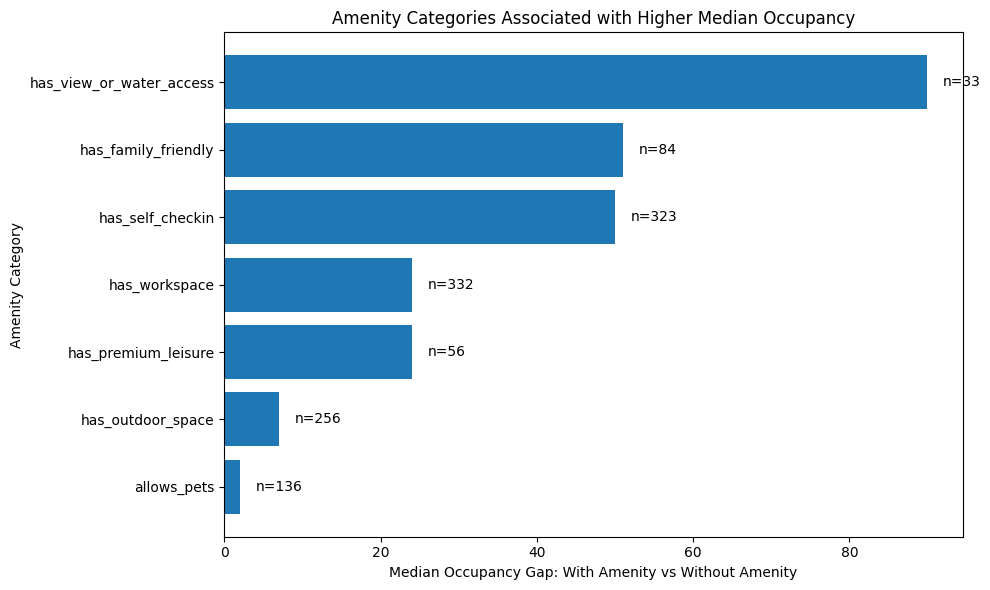

In [228]:
amenity_plot = amenity_impact.sort_values("median_gap")

plt.figure(figsize=(10, 6))

plt.barh(
    amenity_plot["amenity_category"],
    amenity_plot["median_gap"]
)

for i, row in enumerate(amenity_plot.itertuples()):
    plt.text(
        row.median_gap + 2,
        i,
        f"n={row.with_count}",
        va="center"
    )

plt.title("Amenity Categories Associated with Higher Median Occupancy")
plt.xlabel("Median Occupancy Gap: With Amenity vs Without Amenity")
plt.ylabel("Amenity Category")

plt.savefig(
    output_folder / "Amenity Categories and Median Occupancy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()